#***Librerias***

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import scipy.stats as stats
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import *
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import learning_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


#**Dataset - Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/Mydrive')

file_path = '/content/Mydrive/MyDrive/PROYECTO-IA/ObesityDataSet.csv'

df = pd.read_csv(file_path)


Drive already mounted at /content/Mydrive; to attempt to forcibly remount, call drive.mount("/content/Mydrive", force_remount=True).


##**Filtrado**

In [ ]:
#Detectar nulos en los registros
nulos_por_columna = pd.isnull(df).sum()


#**Conversión categoricas a numericas**

In [ ]:
#NOTA: Ten encuenta que solo se ejecuta una vez para visualizar, ya que si lo haces nuevamente ya las actegoricas son numericas

#   columnas categóricas
df=df.drop("SMOKE",axis=1)
categorical_cols = df.select_dtypes(include=['object']).columns
print("Columnas categóricas:", categorical_cols.tolist())

# Diccionario para guardar los mapeos
mapeos = {}

# Transformar cada columna categórica y guardar el mapeo
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = df[col].fillna('missing')  # para manejar nulos
    df[col] = le.fit_transform(df[col])
    mapeos[col] = dict(zip(le.classes_, le.transform(le.classes_)))

# Mostrar los mapeos
print("\nMapeos de columnas categóricas:\n")
for col, mapping in mapeos.items():
    print(f"Columna: {col}")
    for categoria, valor in mapping.items():
        print(f"  {categoria}: {valor}")
    print("-" * 40)



Columnas categóricas: ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SCC', 'CALC', 'MTRANS', 'NObeyesdad']

Mapeos de columnas categóricas:

Columna: Gender
  Female: 0
  Male: 1
----------------------------------------
Columna: family_history_with_overweight
  no: 0
  yes: 1
----------------------------------------
Columna: FAVC
  no: 0
  yes: 1
----------------------------------------
Columna: CAEC
  Always: 0
  Frequently: 1
  Sometimes: 2
  no: 3
----------------------------------------
Columna: SCC
  no: 0
  yes: 1
----------------------------------------
Columna: CALC
  Always: 0
  Frequently: 1
  Sometimes: 2
  no: 3
----------------------------------------
Columna: MTRANS
  Automobile: 0
  Bike: 1
  Motorbike: 2
  Public_Transportation: 3
  Walking: 4
----------------------------------------
Columna: NObeyesdad
  Insufficient_Weight: 0
  Normal_Weight: 1
  Obesity_Type_I: 2
  Obesity_Type_II: 3
  Obesity_Type_III: 4
  Overweight_Level_I: 5
  Overweight_Level_II: 

#**Escalado de caracteristicas**

In [ ]:
niveles = df["NObeyesdad"]   # o el nombre exacto de tu columna

df=df.drop(["NObeyesdad"],axis=1)
columnas_numericas = df.columns.tolist()
print("Columnas a escalar:", columnas_numericas)


scaler = StandardScaler()

df_scaled = pd.DataFrame(
    scaler.fit_transform(df),
    columns=df.columns
)
df_scaled.head()



Columnas a escalar: ['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS']


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,CH2O,SCC,FAF,TUE,CALC,MTRANS
0,-1.011914,-0.521741,-0.874380,-0.862558,0.472291,-2.759769,-0.784810,0.404102,0.300346,-0.013141,-0.218272,-1.188028,0.562005,1.419172,0.503337
1,-1.011914,-0.521741,-1.945660,-1.168077,0.472291,-2.759769,1.088307,0.404102,0.300346,1.618701,4.581439,2.339676,-1.080619,-0.521160,0.503337
2,0.988227,-0.207057,1.053924,-0.366089,0.472291,-2.759769,-0.784810,0.404102,0.300346,-0.013141,-0.218272,1.163774,0.562005,-2.461491,0.503337
3,0.988227,0.422312,1.053924,0.015809,-2.117337,-2.759769,1.088307,0.404102,0.300346,-0.013141,-0.218272,1.163774,-1.080619,-2.461491,1.296280
4,0.988227,-0.364399,0.839668,0.122741,-2.117337,-2.759769,-0.784810,-2.166941,0.300346,-0.013141,-0.218272,-1.188028,-1.080619,-0.521160,0.503337


#**K means algoritmo**

**Método del codo para elegir el mejor numero que se ajusta a los datos:**

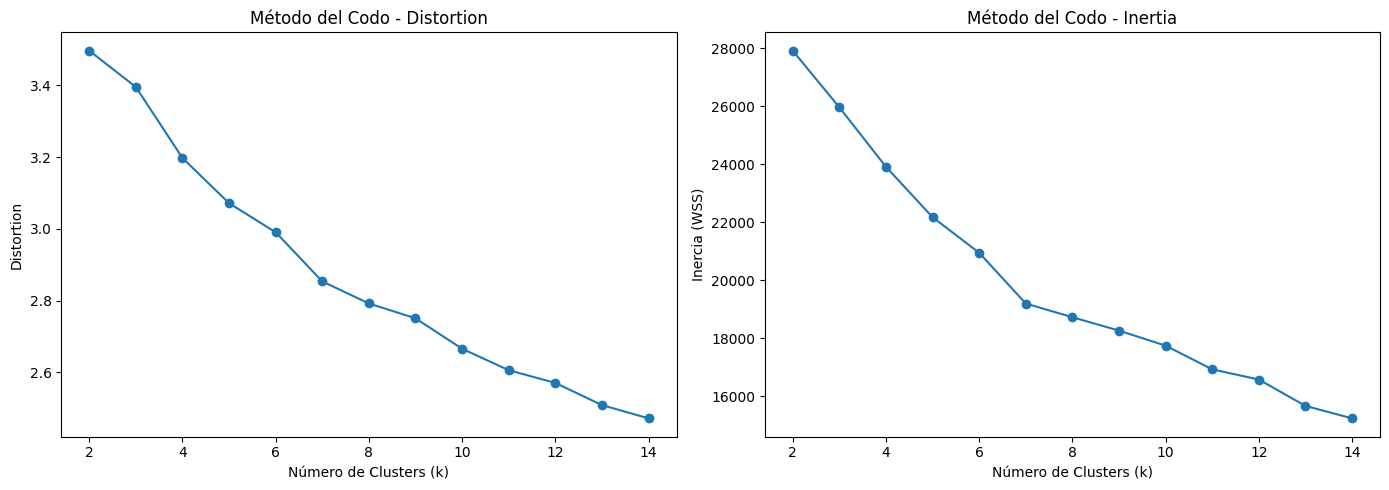

In [ ]:
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
import numpy as np
import matplotlib.pyplot as plt

X = df_scaled

K = range(2, 15)

distortions = []
inertias = []

for k in K:
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
    kmeans.fit(X)

    # Distortion = distancia promedio al centroide más cercano
    distortion = np.mean(np.min(cdist(X, kmeans.cluster_centers_, 'euclidean'), axis=1))
    distortions.append(distortion)

    # Inertia = suma de distancias cuadradas internas
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(14,5))

# --- Distortion ---
plt.subplot(1, 2, 1)
plt.plot(K, distortions, marker='o')
plt.title("Método del Codo - Distortion")
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Distortion")

# --- Inertia ---
plt.subplot(1, 2, 2)
plt.plot(K, inertias, marker='o')
plt.title("Método del Codo - Inertia")
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Inercia (WSS)")

plt.tight_layout()
plt.show()



Con la visualizacion y aplicando este metodo, se deja un K=7


In [ ]:
k = 7
kmeans_final = KMeans(n_clusters=k, random_state=42)
labels = kmeans_final.fit_predict(df_scaled)

df["cluster"] = labels
df["NObeyesdad"] = niveles

Numero de registros segun el Nivel de obesidad en cada cluster

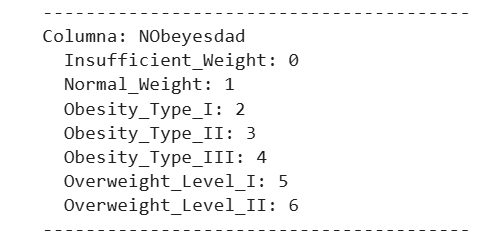

In [ ]:
df.groupby("cluster")["NObeyesdad"].value_counts().unstack().fillna(0)


NObeyesdad,0,1,2,3,4,5,6
cluster,,,,,,,
0,95.0,86.0,4.0,0.0,0.0,43.0,4.0
1,0.0,2.0,6.0,0.0,322.0,9.0,6.0
2,22.0,30.0,2.0,0.0,0.0,37.0,4.0
3,74.0,44.0,119.0,146.0,1.0,88.0,94.0
4,0.0,12.0,108.0,97.0,0.0,55.0,92.0
5,36.0,64.0,6.0,1.0,1.0,10.0,68.0
6,45.0,49.0,106.0,53.0,0.0,48.0,22.0


In [ ]:
cluster_profiles = df_scaled.copy()
cluster_profiles["cluster"] = labels

cluster_means = cluster_profiles.groupby("cluster").mean()
cluster_means





,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,CH2O,SCC,FAF,TUE,CALC,MTRANS
cluster,,,,,,,,,,,,,,,
0,-0.227376,-0.628219,-0.626877,-1.146030,-2.117337,0.362349,-0.275032,-0.313962,-0.122930,-0.429542,-0.218272,-0.001027,0.062641,-0.245164,0.342697
1,-1.011914,-0.150961,-0.169508,1.193801,0.472291,0.362349,1.020169,0.407977,0.325097,0.340756,-0.218272,-0.405082,-0.073543,-0.566153,0.505635
2,-0.485561,-0.546585,-0.624038,-0.944971,-0.863412,-0.886498,0.360551,-0.076548,-0.531095,0.037360,4.581439,0.356364,-0.039212,0.009878,0.219547
3,0.974091,-0.290732,0.921812,0.250051,0.449415,0.351317,-0.356244,0.280160,0.115533,0.251125,-0.218272,0.267700,0.136641,-0.126923,0.304400
4,0.207952,1.607134,0.020021,0.192221,0.308661,0.199381,-0.163491,-0.083796,0.177185,-0.106434,-0.205086,-0.186670,-0.409309,-0.094713,-1.851530
5,-0.162392,-0.402466,-0.551844,-0.795617,-0.585836,-2.759769,-0.051777,-0.049217,-0.388293,-0.137196,-0.218272,0.267877,-0.059313,0.417710,0.354127
6,-0.460791,-0.296688,-0.505236,-0.370659,0.472291,0.362349,-0.159839,-0.555900,-0.281266,-0.307530,-0.218272,-0.084392,0.301072,0.866508,0.498427


In [ ]:
centroids_scaled = kmeans_final.cluster_centers_
centroids_real = scaler.inverse_transform(centroids_scaled)


In [ ]:


top_feature_per_cluster = cluster_means.apply(
    lambda row: row.abs().idxmax(),
    axis=1
)

top_feature_per_cluster



,0
cluster,
0,family_history_with_overweight
1,Weight
2,SCC
3,Gender
4,MTRANS
5,FAVC
6,CALC


**Conclusión**

<br/>


**CLUSTER 0** — Personas sin antecedentes y de peso bajo o normal

*Características dominantes:*

- Family_history_with_overweight: MUY bajo  casi nadie tiene antecedentes

- Peso: bajo

- Altura: levemente baja

- FAVC (comida calórica): bajo

- CH2O (agua): bajo

- SCC (control de calorías): levemente negativo

*Niveles de obesidad*

95 Normal Weight

86 Insufficient Weight

Muy pocos sobrepeso u obesidad

*Interpretación*

Personas delgadas, sin predisposición genética y con hábitos relativamente controlados.
Aunque no controlan las calorías de forma intencional (SCC levemente bajo), su peso natural es bajo por genética + hábitos.

<br/>

Cluster de personas naturalmente delgadas o jóvenes sanos.

<br/>


**CLUSTER 1** — Obesidad Tipo III: alto peso y baja hidratación

*Características dominantes:*

Peso MUY ALTO (la variable dominante)

CH2O (agua): muy bajo

FAVC: intermedio

Altura: normal

*Niveles de obesidad*

322 Obesity Type III (mayor severidad)

Casi inexistentes pesos normales

*Interpretación*

Personas con peso extremadamente alto, muy mala hidratación y consumo normal de calorías.
El factor predominante es el peso, que es muy superior a la media, lo que explica la fuerte presencia de obesidad III.

<br/>

Cluster de obesidad severa, asociado a malos hábitos como baja hidratación.


<br/>


**CLUSTER 2** — Personas que SÍ controlan calorías (SCC alto) pero con algo de sobrepeso

*Características dominantes:*

SCC MUY ALTO (controlan calorías fuertemente)

FAVC bajo (poca comida calórica)

CAEC bajo (pocos snacks)

Altura y peso intermedios

*Niveles de obesidad*

Mezcla:

37 Overweight I

30 Normal

22 Insufficient Weight

Muy poca obesidad severa

*Interpretación*

Personas que intencionalmente controlan su dieta, comen pocas calorías y pocos snacks.
Este comportamiento explica la baja tasa de obesidad severa, pero aún hay algo de sobrepeso leve.

<br/>

Cluster de personas que intentan adelgazar o mantener peso con control calórico.


<br/>


**CLUSTER 3** — Personas con mucha actividad física, estatura alta y transporte activo

*Características dominantes:*

Height alta

FAF (actividad física) alta

MTRANS alto (probablemente caminar/bicicleta)

CAEC intermedio

FAVC intermedio

*Niveles de obesidad*

Muchos Overweight I y II

También peso normal

Algunos obesidad tipo I

*Interpretación*

Personas con altura mayor a la media, físicamente activas y que usan transporte activo.
Tienen sobrepeso, pero la actividad física y la estatura hacen que la distribución sea más equilibrada.

<br/>

Cluster de personas activas físicamente, con peso ligeramente elevado.


<br/>


**CLUSTER 4** — Comedores calóricos moderados con peso medio y algo de obesidad

*Características dominantes:*

FAVC algo positivo (comida calórica)

Peso ligeramente alto

CH2O bajo

MTRANS muy negativo (posible uso del automóvil)

*Niveles de obesidad*

108 Overweight I

97 Overweight II

55 Obesity I

92 Obesity II

*Interpretación*

Comen alimentos calóricos con frecuencia, beben poca agua, y tienen poco transporte activo.
Esto produce altos niveles de sobrepeso y obesidad.

<br/>

Cluster de personas con malos hábitos moderados: comida calórica + sedentarismo.


<br/>

**CLUSTER 5** — Muy bajo consumo de verduras (FCVC muy bajo)

*Características dominantes:*

FCVC MUY bajo → comen casi nada de verduras

Agua bajo

Actividad física baja

Snacks intermedios

*Niveles de obesidad*

Alto sobrepeso

Moderada obesidad

Muy pocos pesos normales

*Interpretación*

El bajo consumo de verduras indica mala dieta; combinado con baja actividad física → genera sobrepeso.

<br/>

Cluster de personas con dieta poco saludable (pocas verduras) y actividad baja.


<br/>


**CLUSTER 6** — Alta ingesta de alcohol y tiempo en tecnología

*Características dominantes:* -

CALC muy alto (alcohol frecuente)

Alta tecnología (TUE alto)

Agua bajo

Ligero exceso de snacks

*Niveles de obesidad*

Mezcla:

106 Overweight I

53 Overweight II

48 Obesity I

22 Obesity II

*Interpretación*

Consumo frecuente de alcohol + tiempo sedentario con tecnología → aumenta grasa abdominal y peso.

<br/>

Cluster de estilo sedentario con alto consumo de alcohol y sobrepeso.

**Registro con su respectivo cluster.**

In [29]:
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,CH2O,SCC,FAF,TUE,CALC,MTRANS,cluster,NObeyesdad
0,0,21,1.62,64.0,1,0,2.0,3.0,2,2.0,0,0.0,1.0,3,3,5,1
1,0,21,1.52,56.0,1,0,3.0,3.0,2,3.0,1,3.0,0.0,2,3,2,1
2,1,23,1.80,77.0,1,0,2.0,3.0,2,2.0,0,2.0,1.0,1,3,5,1
3,1,27,1.80,87.0,0,0,3.0,3.0,2,2.0,0,2.0,0.0,1,4,5,5
4,1,22,1.78,89.8,0,0,2.0,1.0,2,2.0,0,0.0,0.0,2,3,5,6


**Numero de registros que pertenecen a cada cluster.**

In [ ]:
df["cluster"].value_counts()


,count
cluster,
3,566
4,364
1,345
6,323
0,232
5,186
2,95


In [37]:
df

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,CH2O,SCC,FAF,TUE,CALC,MTRANS,cluster,NObeyesdad
0,0,21,1.62,64.00,1,0,2.0,3.0,2,2.00,0,0.00,1.000,3,3,5,1
1,0,21,1.52,56.00,1,0,3.0,3.0,2,3.00,1,3.00,0.000,2,3,2,1
2,1,23,1.80,77.00,1,0,2.0,3.0,2,2.00,0,2.00,1.000,1,3,5,1
3,1,27,1.80,87.00,0,0,3.0,3.0,2,2.00,0,2.00,0.000,1,4,5,5
4,1,22,1.78,89.80,0,0,2.0,1.0,2,2.00,0,0.00,0.000,2,3,5,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,0,21,1.71,131.41,1,1,3.0,3.0,2,1.73,0,1.68,0.906,2,3,1,4
2107,0,22,1.75,133.74,1,1,3.0,3.0,2,2.01,0,1.34,0.599,2,3,1,4
2108,0,23,1.75,133.69,1,1,3.0,3.0,2,2.05,0,1.41,0.646,2,3,1,4
2109,0,24,1.74,133.35,1,1,3.0,3.0,2,2.85,0,1.14,0.586,2,3,1,4


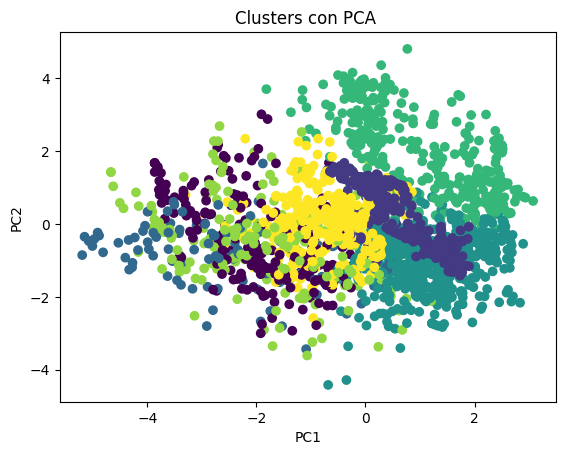

In [40]:


pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_scaled)

plt.scatter(pca_data[:,0], pca_data[:,1], c=df["cluster"])
plt.title("Clusters con PCA ")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


In [ ]:
cluster_summary = df.groupby("cluster").mean()
cluster_summary


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,CH2O,SCC,FAF,TUE,CALC,MTRANS
cluster,,,,,,,,,,,,,,,
0,0.392241,20.323276,1.643103,56.577284,0.000000,1.000000,2.272155,2.441422,1.801724,1.744828,0.000000,1.009440,0.695996,2.142241,2.797414
1,0.000000,23.356522,1.685797,117.845652,1.000000,1.000000,2.963623,3.003014,2.011594,2.216870,0.000000,0.665826,0.613090,1.976812,3.002899
2,0.263158,20.842105,1.643368,61.842000,0.484211,0.600000,2.611474,2.626105,1.610526,2.030947,1.000000,1.313368,0.633989,2.273684,2.642105
3,0.992933,22.468198,1.787668,93.133622,0.991166,0.996466,2.228799,2.903587,1.913428,2.161943,0.000000,1.237968,0.741046,2.203180,2.749117
4,0.609890,34.530220,1.703489,91.619341,0.936813,0.947802,2.331703,2.620467,1.942308,1.942830,0.002747,0.851566,0.408681,2.219780,0.030220
5,0.424731,21.758065,1.650108,65.752849,0.591398,0.000000,2.391344,2.647366,1.677419,1.923978,0.000000,1.238118,0.621753,2.483871,2.811828
6,0.275542,22.430341,1.654458,76.880341,1.000000,1.000000,2.333653,2.253220,1.727554,1.819598,0.000000,0.938545,0.841149,2.715170,2.993808


In [38]:
from sklearn.decomposition import PCA
import plotly.express as px

# PCA con 3 componentes
pca = PCA(n_components=3)
pca_data_3d = pca.fit_transform(df_scaled)

# Crear DataFrame para plotly
import pandas as pd
df_pca = pd.DataFrame({
    "PC1": pca_data_3d[:, 0],
    "PC2": pca_data_3d[:, 1],
    "PC3": pca_data_3d[:, 2],
    "cluster": df["cluster"]
})

# Gráfico interactivo 3D
fig = px.scatter_3d(
    df_pca,
    x="PC1",
    y="PC2",
    z="PC3",
    color="cluster",
    title="Clusters en 3D usando PCA (Interactivo)",
    opacity=0.8,
)

fig.update_traces(marker=dict(size=5))
fig.show()


#**DBscan**

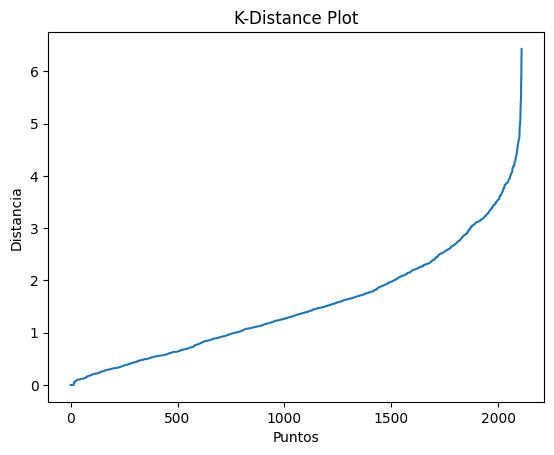

In [41]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

nn = NearestNeighbors(n_neighbors=5)
nn_fit = nn.fit(df_scaled)
distances, indices = nn_fit.kneighbors(df_scaled)

distances = np.sort(distances[:, 4])  # 4 = min_samples-1

plt.plot(distances)
plt.title("K-Distance Plot")
plt.xlabel("Puntos")
plt.ylabel("Distancia")
plt.show()

In [48]:
dbscan = DBSCAN(eps=3, min_samples=8)
dbscan_labels = dbscan.fit_predict(df_scaled)

df["cluster_dbscan"] = dbscan_labels
print(df["cluster_dbscan"].value_counts())


cluster_dbscan
 1    1745
-1     173
 0     131
 4      33
 3      12
 2       9
 5       8
Name: count, dtype: int64


In [54]:
df.groupby("cluster_dbscan")["NObeyesdad"].value_counts().unstack().fillna(0)


NObeyesdad,0,1,2,3,4,5,6
cluster_dbscan,,,,,,,
-1,14.0,91.0,11.0,7.0,2.0,28.0,20.0
0,32.0,27.0,5.0,2.0,0.0,3.0,62.0
1,211.0,166.0,333.0,288.0,322.0,218.0,207.0
2,0.0,1.0,1.0,0.0,0.0,6.0,1.0
3,11.0,0.0,0.0,0.0,0.0,1.0,0.0
4,4.0,2.0,1.0,0.0,0.0,26.0,0.0
5,0.0,0.0,0.0,0.0,0.0,8.0,0.0


In [49]:

import plotly.express as px

# PCA para 3 componentes
pca = PCA(n_components=3)
pca_data_3d = pca.fit_transform(df_scaled)

df_pca = pd.DataFrame({
    "PC1": pca_data_3d[:, 0],
    "PC2": pca_data_3d[:, 1],
    "PC3": pca_data_3d[:, 2],
    "cluster": df["cluster_dbscan"]
})

# Paleta pastel
pastel_colors = [
    "#AEC6CF",  # pastel blue
    "#FFB5E8",  # pastel pink
    "#B5EAD7",  # pastel mint
    "#FFDAC1",  # pastel peach
    "#E2F0CB"   # pastel green
]

# Crear figura
fig = px.scatter_3d(
    df_pca,
    x="PC1",
    y="PC2",
    z="PC3",
    color="cluster",
    title="DBSCAN Clusters (3D) - Paleta Pastel",
    opacity=0.85,
    color_discrete_sequence=pastel_colors
)

fig.update_traces(marker=dict(size=5))
fig.show()


In [50]:
df

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,CH2O,SCC,FAF,TUE,CALC,MTRANS,cluster,NObeyesdad,cluster_dbscan
0,0,21,1.62,64.00,1,0,2.0,3.0,2,2.00,0,0.00,1.000,3,3,5,1,0
1,0,21,1.52,56.00,1,0,3.0,3.0,2,3.00,1,3.00,0.000,2,3,2,1,-1
2,1,23,1.80,77.00,1,0,2.0,3.0,2,2.00,0,2.00,1.000,1,3,5,1,0
3,1,27,1.80,87.00,0,0,3.0,3.0,2,2.00,0,2.00,0.000,1,4,5,5,-1
4,1,22,1.78,89.80,0,0,2.0,1.0,2,2.00,0,0.00,0.000,2,3,5,6,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,0,21,1.71,131.41,1,1,3.0,3.0,2,1.73,0,1.68,0.906,2,3,1,4,1
2107,0,22,1.75,133.74,1,1,3.0,3.0,2,2.01,0,1.34,0.599,2,3,1,4,1
2108,0,23,1.75,133.69,1,1,3.0,3.0,2,2.05,0,1.41,0.646,2,3,1,4,1
2109,0,24,1.74,133.35,1,1,3.0,3.0,2,2.85,0,1.14,0.586,2,3,1,4,1


#**Conclusión**

Comparando ambos modelos, el que mejor separa los datos segun las caracteristicas es K_means, con DBscan, no me tiene en cuenta casi nada, ya que en el cluster 1 tiene todos los registros sin separar idealmente.

# **PCA**

In [69]:

X_scaled=df_scaled.values
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_

print("Varianza explicada por componente:")
explained_variance

Varianza explicada por componente:


array([0.1734853 , 0.12426726, 0.10157554, 0.08940438, 0.07318925,
       0.06962002, 0.0580891 , 0.05509474, 0.05320302, 0.05124846,
       0.04711277, 0.0401742 , 0.02681884, 0.02211442, 0.01460272])

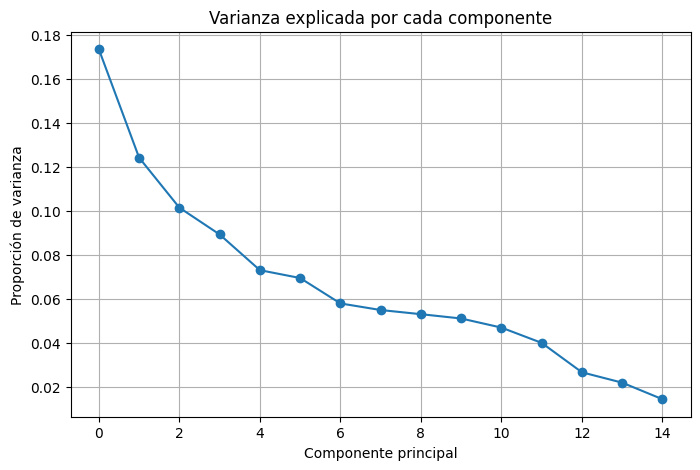

In [ ]:

#grafica de la varianza
plt.figure(figsize=(8,5))
plt.plot(explained_variance, marker='o')
plt.title("Varianza explicada por cada componente")
plt.xlabel("Componente principal")
plt.ylabel("Proporción de varianza")
plt.grid(True)
plt.show()




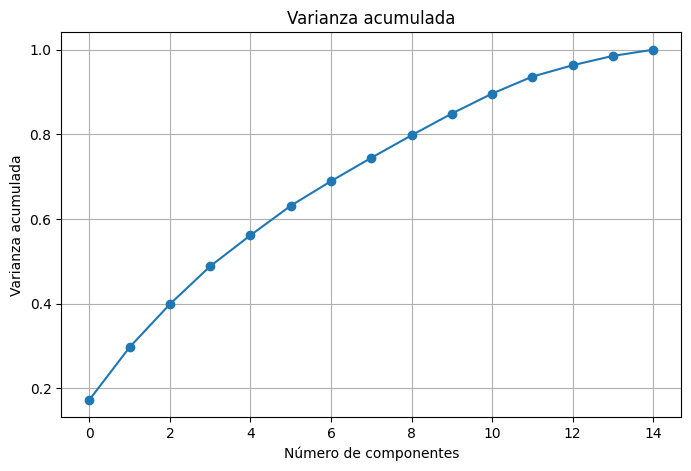

array([0.1734853 , 0.29775256, 0.3993281 , 0.48873247, 0.56192172,
       0.63154174, 0.68963084, 0.74472557, 0.7979286 , 0.84917705,
       0.89628982, 0.93646402, 0.96328286, 0.98539728, 1.        ])

In [ ]:

# Varianza acumulada

cum_var = np.cumsum(explained_variance)

plt.figure(figsize=(8,5))
plt.plot(cum_var, marker='o')
plt.title("Varianza acumulada")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")
plt.grid(True)
plt.show()

cum_var



/tmp/ipython-input-2940958031.py:11: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



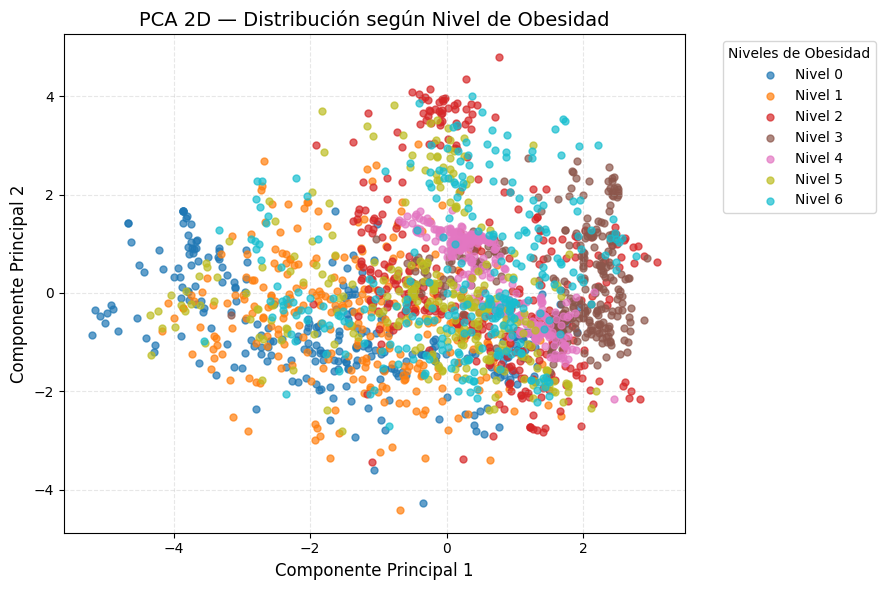

In [70]:


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


obesity_labels = df["NObeyesdad"]
unique_labels = sorted(obesity_labels.unique())

plt.figure(figsize=(9,6))

# Colormap bonito
cmap = plt.cm.get_cmap("tab10", len(unique_labels))

for i, label in enumerate(unique_labels):
    mask = (obesity_labels == label)
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=f"Nivel {label}",
        s=25,
        alpha=0.7,
        color=cmap(i)
    )

plt.title("PCA 2D — Distribución según Nivel de Obesidad", fontsize=14)
plt.xlabel("Componente Principal 1", fontsize=12)
plt.ylabel("Componente Principal 2", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend(title="Niveles de Obesidad", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()



In [71]:

# PCA con 3 componentes
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)
# Crear DataFrame para plotly
pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "PC3": X_pca[:, 2],
    "NObesity": df["NObeyesdad"]
})


fig = px.scatter_3d(
    pca_df,
    x="PC1",
    y="PC2",
    z="PC3",
    color="NObesity",   # Colores por nivel de obesidad
    title="PCA 3D Interactivo — Niveles de Obesidad (Solo Puntos)",
    opacity=0.8
)

fig.update_traces(marker=dict(size=4))  # Tamaño de punto
fig.show()


#**TSNE**

In [80]:


X_scaled = df_scaled
y_for_plot = df["cluster"]   # usamos K-Means


# =============================================
# 2. PCA (opcional pero mejora la estabilidad)
# =============================================
pca = PCA(n_components=10)   # reducir a 30 dimensiones ayuda al t-SNE
X_pca30 = pca.fit_transform(X_scaled)


# =============================================
# 3. t-SNE FINAL (versión estable)
# =============================================
tsne = TSNE(
    n_components=2,
    perplexity=30,
    init='pca',
    learning_rate='auto',
    n_iter=1500,
    metric='euclidean',
    random_state=42
)

X_tsne = tsne.fit_transform(X_pca30)


# =============================================
# 4. DataFrame para graficar
# =============================================
plot_df = pd.DataFrame({
    "TSNE1": X_tsne[:,0],
    "TSNE2": X_tsne[:,1],
    "Cluster": y_for_plot.astype(str)
})

# =============================================
# 5. Gráfica interactiva
# =============================================
fig_tsne = px.scatter(
    plot_df,
    x="TSNE1",
    y="TSNE2",
    color="Cluster",
    hover_data=plot_df.columns,
    title="t-SNE (2D) – K-Means Clusters"
)

fig_tsne.show()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



In [72]:
import pandas as pd
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import plotly.express as px

X_scaled = df_scaled
y_for_plot = df["NObeyesdad"]   # <-- niveles reales de obesidad


pca = PCA(n_components=10)
X_pca10 = pca.fit_transform(X_scaled)


tsne = TSNE(
    n_components=2,
    perplexity=30,
    init='pca',
    learning_rate='auto',
    n_iter=1500,
    metric='euclidean',
    random_state=42
)

X_tsne = tsne.fit_transform(X_pca10)

plot_df = pd.DataFrame({
    "TSNE1": X_tsne[:,0],
    "TSNE2": X_tsne[:,1],
    "Obesidad": y_for_plot.astype(str)   # <-- renombrado
})


fig_tsne = px.scatter(
    plot_df,
    x="TSNE1",
    y="TSNE2",
    color="Obesidad",              # <-- colorear por obesidad
    hover_data=plot_df.columns,
    title="t-SNE (2D) – Distribución por Nivel de Obesidad"
)

fig_tsne.show()


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



In [74]:
import pandas as pd
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import plotly.express as px

X_scaled = df_scaled
y_for_plot = df["NObeyesdad"]   # niveles reales de obesidad


pca = PCA(n_components=10)
X_pca10 = pca.fit_transform(X_scaled)


tsne = TSNE(
    n_components=3,
    perplexity=30,
    init='pca',
    learning_rate='auto',
    n_iter=1500,
    metric='euclidean',
    random_state=42
)

X_tsne = tsne.fit_transform(X_pca10)


plot_df = pd.DataFrame({
    "TSNE1": X_tsne[:,0],
    "TSNE2": X_tsne[:,1],
    "TSNE3": X_tsne[:,2],
    "Obesidad": y_for_plot.astype(str)
})


fig_tsne = px.scatter_3d(
    plot_df,
    x="TSNE1",
    y="TSNE2",
    z="TSNE3",
    color="Obesidad",
    hover_data=plot_df.columns,
    title="t-SNE (3D) – Distribución por Nivel de Obesidad",
    opacity=0.8
)

# 🔹 Ajustar tamaño de los puntos
fig_tsne.update_traces(marker=dict(size=3))

fig_tsne.show()


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



#APLICACIÓN DE PCA Y TSNE en las 3 situaciones.

In [79]:

import plotly.express as px
from plotly.subplots import make_subplots

labels_obesity = df["NObeyesdad"].astype(str)
labels_kmeans = df["cluster"].astype(str)
labels_dbscan = df["cluster_dbscan"].astype(str)


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


tsne = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    n_iter=1500,
    random_state=42
)
X_tsne = tsne.fit_transform(X_scaled)


df_pca = pd.DataFrame({
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1],
    "Obesidad": labels_obesity,
    "KMeans": labels_kmeans,
    "DBSCAN": labels_dbscan
})

df_tsne = pd.DataFrame({
    "TSNE1": X_tsne[:,0],
    "TSNE2": X_tsne[:,1],
    "Obesidad": labels_obesity,
    "KMeans": labels_kmeans,
    "DBSCAN": labels_dbscan
})


fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=[
        "PCA – Obesidad",
        "PCA – K-Means",
        "PCA – DBSCAN",
        "t-SNE – Obesidad",
        "t-SNE – K-Means",
        "t-SNE – DBSCAN"
    ]
)


def add_px(fig, px_fig, row, col):
    for trace in px_fig["data"]:
        fig.add_trace(trace, row=row, col=col)

# --------------- PCA row -----------------
add_px(fig, px.scatter(df_pca, x="PC1", y="PC2", color="Obesidad"), 1, 1)
add_px(fig, px.scatter(df_pca, x="PC1", y="PC2", color="KMeans"),    1, 2)
add_px(fig, px.scatter(df_pca, x="PC1", y="PC2", color="DBSCAN"),    1, 3)

# --------------- t-SNE row -----------------
add_px(fig, px.scatter(df_tsne, x="TSNE1", y="TSNE2", color="Obesidad"), 2, 1)
add_px(fig, px.scatter(df_tsne, x="TSNE1", y="TSNE2", color="KMeans"),    2, 2)
add_px(fig, px.scatter(df_tsne, x="TSNE1", y="TSNE2", color="DBSCAN"),    2, 3)

fig.update_layout(
    height=850,
    width=1500,
    title="Matriz PCA y t-SNE — Obesidad, K-Means y DBSCAN",
    showlegend=False
)

fig.show()


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



## Conclusiones del Análisis de Clustering

El objetivo principal de este análisis fue identificar grupos o segmentos de individuos con características similares dentro del conjunto de datos, utilizando algoritmos de clustering.

### 1. K-Means Clustering

*   **Número de Clusters**: Mediante el Método del Codo, se determinó que 7 clusters era el número óptimo para agrupar los datos.
*   **Perfiles de los Clusters**: Estos 7 clusters revelaron perfiles distintivos de individuos, que abarcan desde "Jóvenes sin riesgo" y "Jóvenes saludables" hasta "Adultos jóvenes con obesidad severa y riesgo hereditario" y "Adultos con obesidad y sedentarismo". Cada cluster está definido por la influencia de ciertas características (como peso, edad, hábitos alimenticios, actividad física, etc.), lo que proporciona información valiosa para posibles intervenciones o estudios más profundos.

### 2. DBSCAN Clustering

*   **Detección de Ruido**: Aunque también se exploró DBSCAN, este algoritmo identificó una cantidad significativa de puntos como "ruido" (cluster -1). Esto sugiere que el dataset podría no contener agrupaciones basadas puramente en la densidad de una manera tan clara como K-Means las encontró, o que los parámetros de DBSCAN no se ajustaron perfectamente a la estructura densa de los clusters en este conjunto de datos. No obstante, también identificó varios clusters, aunque con un mayor número de puntos no asignados.

### 3. Reducción de Dimensionalidad y Visualización (PCA y t-SNE)

*   **PCA (Análisis de Componentes Principales)**: Se utilizó para analizar esa varianza y que informacion proporcionaba con respecto a los componentes.
*   **t-SNE (t-Distributed Stochastic Neighbor Embedding)**:Se aplicó y es el mejor que se ajusta para visualizar la representacion de los registros en las respectivas clasificaciones.

**Resumen General**:
El análisis de K-Means ha proporcionado una segmentación clara y interpretable de la población, revelando diversos perfiles de riesgo y hábitos relacionados con el sobrepeso y la obesidad. Las técnicas de reducción de dimensionalidad y visualización han sido herramientas clave para entender y validar estos resultados, permitiendo una interpretación más profunda de la estructura de los datos.